# PQC 심화 강의 노트북 — 실제 구현과 하드웨어 보안
## Advanced PQC: From Lattice Mathematics to Hardware Security

---

이 노트북은 **격자 기반 양자내성암호(PQC)가 실제 칩·임베디드 기기 위에서 어떻게 구현되는지**를
**비전공자도 따라올 수 있도록** 쉽게 풀어 쓴 **선택적 심화 강의 자료**입니다.
앞선 개념·표준 노트북만으로도 입문에는 충분하며, 이 노트북을 건너뛰어도 무방합니다.

핵심 질문은 하나입니다 — **"수학적으로 안전한 암호 설계도가 있다고 해서, 그것이 실제 기계
위에서도 빠르고 안전하게 돌아갈까?"** 좋은 요리 레시피(알고리즘)가 있어도, 주방 설비(하드웨어)와
조리 습관(구현)이 나쁘면 요리를 망치는 것과 같습니다. 이 노트북은 그 "주방"을 다룹니다.

수학적 구조(LWE → RLWE → Module-LWE, 즉 키를 작게 압축하는 방법) → 고속 계산 기법(NTT) →
씨앗 압축(Keccak/SHAKE) → 구현 보안(계산 중 새는 정보 막기) → 전용 하드웨어 명령어(RISC-V PQC ISA)
순서로 실행 코드와 함께 확인합니다.

본문은 두 설계 문서 — **「LWE→RLWE→NTT→Keccak / RV-PQC 설계 리포트」** 와
**「PQC ISA 보안·패치 사양」** — 의 핵심 내용을 실행 코드로 재현합니다.

| 장 | 주제 | 출처 문서 |
|---|---|---|
| 1 | LWE → RLWE → Module-LWE (수학적 진화) | RV-PQC 리포트 §2·3, App.A |
| 2 | NTT — 다항식 곱을 $O(n\log n)$ 으로 | RV-PQC 리포트 §4 |
| 3 | Keccak/SHAKE — 시드 확장 | RV-PQC 리포트 §5 |
| 4 | 사이드채널 방어 — 상수시간·스크램블·마스킹 | PQC ISA §2·3·6 |
| 5 | RISC-V PQC ISA 매핑 개관 | PQC ISA §3·4 |

### 학습 목표
1. LWE(큰 표)가 RLWE(다항식 한 줄)·Module-LWE(다항식 묶음)로 진화하며 키가 작아진 이유를 이해한다.
2. NTT라는 "빠른 곱셈 기법"이 다항식 곱을 얼마나 가속하는지 직접 만든 코드로 확인한다.
3. SHAKE 기반 **시드 확장**("표 대신 씨앗만 보내기")이 공개키 크기를 줄이는 방식을 이해한다.
4. 계산 시간의 미세한 차이로 비밀이 새는 것(타이밍 사이드채널)을 실측하고, 방어법 3종
   (상수시간·스크램블·마스킹)을 구현한다.
5. 위 연산들이 RISC-V **전용 명령어(PQC ISA)** 로 어떻게 옮겨지는지 큰 그림을 잡는다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제를 분리·정리한
> 강의 자료입니다. 실행 셀과 출력은 원본 그대로 보존되어 있으며, 재실행하려면
> **0장(Setup)의 공통 설정 셀을 먼저 실행**해야 합니다.

> **선행 지식**: "나머지 구하기(mod)"의 개념, LWE 문제($b = As + e$, 즉 "잡음 섞인 연립방정식은
> 풀기 어렵다")의 기본 아이디어, 기초 Python/NumPy. 수식이 나오면 바로 아래에 쉬운 풀이를 붙였습니다.


## 0. 준비 (Setup)

아래 셀은 시리즈 전체가 공유하는 **공통 도구 상자(하니스, harness)** 입니다.
`numpy`, `pandas`, `matplotlib` 를 불러오고, 그래프의 한글이 깨지지 않도록 폰트를 자동 설정합니다.
이후 장에서 쓸 공통 도구 — 해시 헬퍼(`H`: SHA-256, `shake`: SHAKE-128),
대략적 전송량 측정(`nbytes`), 시간 측정(`timeit`), 측정값 저장소(`METRICS` / `log_metric`) — 도
여기서 정의합니다.

> 아래 셀을 실행하면 "Harness 준비 완료" 메시지와 함께 Python·NumPy 버전,
> 감지된 한글 폰트 이름이 출력됩니다.


In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. LWE → RLWE → Module-LWE — 왜 다항식으로 갔는가

**LWE**는 $b = As + e$, 즉 "잡음을 섞은 연립방정식"을 큰 **표(행렬)** 로 다룹니다.

> **수식 풀이:** $A$ 는 공개된 큰 숫자표, $s$ 는 비밀 숫자들, $e$ 는 일부러 섞는 작은 잡음,
> $b$ 는 그 계산 결과입니다. 잡음 때문에 $b$ 와 $A$ 만 보고 $s$ 를 알아내기가 매우 어렵다는 것이
> 격자 암호의 안전성 근거였습니다.

그런데 문제가 하나 있습니다 — 안전할 만큼 차원을 키우면 **표 $A$ 가 지나치게 커집니다**
(수십만 개의 숫자). 이를 해결하려고 표를 **다항식**(계수 목록 한 줄)으로 바꾼 것이
**RLWE(Ring-LWE)** 입니다:

$$ b(x) = a(x)\,s(x) + e(x) $$

> **수식 풀이:** 행렬·벡터가 하던 역할을 다항식 $a(x), s(x), e(x)$ 가 대신합니다.
> 곱셈 결과의 차수가 넘치면 $x^n = -1$ 이라는 규칙으로 접어 내립니다(부호를 뒤집으며 되돌아옴).

핵심 관찰(RV-PQC 리포트 §2·3)은 다음과 같습니다.

> **다항식 곱 $a(x)\cdot s(x) \bmod (x^n+1)$ 은, $a$ 로 만든 음순환행렬(nega-circulant matrix)과
> $s$ 의 행렬-벡터 곱과 정확히 같다.**

음순환행렬이란 첫 행(다항식 계수)을 **한 칸씩 옆으로 밀며** 줄줄이 채우되, 밀려서 넘어간 자리는
$x^n = -1$ 규칙 때문에 **부호를 뒤집어** 넣은 행렬입니다. 즉 행렬 전체가 사실은
**첫 줄 하나의 복사·회전에 불과**하므로, 표 전체 대신 **첫 줄(다항식 계수)만 저장하면 됩니다.**
노래 전체를 저장하는 대신 악보 첫 소절과 "반복 규칙"만 저장하는 것과 같습니다 —
이것이 RLWE에서 키가 크게 줄어드는 이유입니다. **RLWE는 LWE의 압축판일 뿐, 본질은 같습니다.**

Kyber는 여기서 한 걸음 더 나아가, 다항식들을 작은 벡터·행렬로 묶는 **Module-LWE** 를 사용합니다.
하나의 링(반복 규칙)만 쓰면 그 규칙성(대칭성) 자체가 공격의 실마리가 될 수 있어서,
다항식 여러 개를 묶어 그 편향을 완화한 것입니다.

### 1-1. 검증 — 음순환행렬 등가성

아래 셀은 $n=8$, $q=257$ 에서 무작위 다항식 500쌍에 대해 "다항식 곱 == 음순환행렬 곱"이
정말 성립하는지 직접 확인하고, 예시 다항식 $a(x)=1+2x+3x^2+4x^3$ 의 음순환행렬을
색깔 지도(히트맵)로 시각화합니다.


다항식 곱 == 음순환행렬 곱 : 500/500
→ RLWE는 LWE(행렬)를 다항식으로 압축한 것. 구조는 같고 저장·연산만 효율적.


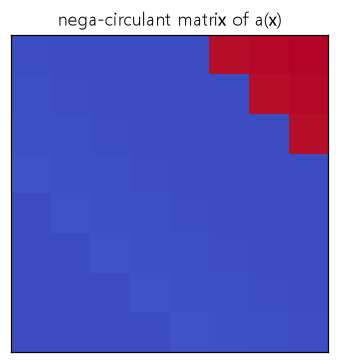

In [29]:
# ③④ 음순환행렬 등가성: a(x)*s(x) mod (x^n+1)  ==  negacirc(a) @ s
def poly_mul_neg(a, b, n, q):                  # x^n+1 위 다항식 곱
    r = np.zeros(2*n-1, dtype=np.int64)
    for i in range(n): r[i:i+n] += a[i]*b
    out = r[:n].copy(); out[:n-1] -= r[n:2*n-1]
    return out % q

def negacirc(a, n, q):                          # a 의 음순환행렬
    M = np.zeros((n, n), dtype=np.int64)
    for i in range(n):
        for j in range(n):
            k = i - j
            M[i, j] = a[k] % q if k >= 0 else (-a[k+n]) % q
    return M

n, q = 8, 257
ok = 0
for _ in range(500):
    a = RNG.integers(0, q, n); s = RNG.integers(0, q, n)
    ok += np.array_equal(poly_mul_neg(a, s, n, q), (negacirc(a, n, q) @ s) % q)
print(f'다항식 곱 == 음순환행렬 곱 : {ok}/500')
print('→ RLWE는 LWE(행렬)를 다항식으로 압축한 것. 구조는 같고 저장·연산만 효율적.')
# 순환행렬 시각화
a_demo = np.array([1,2,3,4,0,0,0,0])
fig, ax = plt.subplots(figsize=(3.6,3.4))
ax.imshow(negacirc(a_demo, 8, 257), cmap='coolwarm')
ax.set_title('nega-circulant matrix of a(x)'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
log_metric('RLWE', equiv='poly==negacirc', ring='Z_q[x]/(x^n+1)')

### 1-2. 결과 해석

출력 `500/500` 은 무작위 500회 모두에서 다항식 곱과 음순환행렬 곱이 정확히 일치했다는 뜻입니다 —
"다항식 한 줄 = 큰 행렬"이라는 압축 등식이 실제로 성립합니다.

그림에서는 같은 값이 **대각선을 따라 한 칸씩 밀려 내려가는** 규칙적인 줄무늬가 보입니다.
오른쪽 위 영역의 색이 반전된 것은 $x^n = -1$ 규칙 때문에 부호가 뒤집힌 자리입니다.
행렬 전체가 첫 행 하나(다항식 계수)의 복사·회전일 뿐이므로, 큰 행렬을 통째로 저장할 필요 없이
**다항식 한 줄만 저장하면 됩니다.** LWE(행렬)에서 RLWE(다항식)로 넘어가며 키가 작아지는 이유가
이 그림 한 장에 담겨 있습니다.

### 1-3. 의미

- 격자 서명·KEM이 "다항식 곱"을 핵심 연산으로 삼는 이유가 여기에 있습니다.
  이 곱을 얼마나 빨리 하느냐가 곧 암호 전체의 속도이며, 다음 장의 **NTT** 로 이어집니다.
- RV-PQC 리포트 App.A: RLWE는 링의 규칙성(대칭성) 때문에 잠재적 약점이 지적되었지만,
  NIST 표준(Kyber/Dilithium)은 **원분다항식 $x^n+1$**(접는 규칙의 안전한 선택),
  **CBD(중심 이항 분포) 노이즈**(잡음을 만드는 안전한 방법), **Module-LWE 확장**(다항식 묶기)으로
  이를 모두 완화했습니다.
- Kyber·Dilithium의 키가 실용적인 크기인 것은 이 "구조로 압축하기" 덕분입니다.

> **정리**: LWE(큰 표) → RLWE(다항식 한 줄) → Module-LWE(다항식 묶음)로 갈수록
> 같은 안전성을 더 작고 빠르게 담습니다. 실제 표준은 이 마지막 단계에 서 있습니다.


## 2. NTT (수론 변환) — 다항식 곱을 $O(n\log n)$ 으로

다항식 곱을 정의대로 — 모든 항을 하나하나 곱해서 더하는 방식(schoolbook, 초등학교 세로셈 방식) —
계산하면 계수가 $n$ 개일 때 곱셈이 약 $n^2$ 번 필요합니다. $n$ 이 2배가 되면 일이 4배가 되는
방식입니다.

**NTT(Number Theoretic Transform, 수론 변환)** 는 음악 앱의 이퀄라이저가 소리를 주파수별로
분해하듯, 다항식을 "다른 표현 영역"으로 변환해서 곱셈을 쉽게 만드는 기법입니다.
(신호처리의 FFT라는 유명한 고속 변환을, 소수점 대신 "나머지 연산(mod $q$)의 세계"에서
수행한 것입니다.)

$$ \text{NTT} \;\longrightarrow\; \text{점별곱} \;\longrightarrow\; \text{iNTT} $$

> **수식 풀이:** ① 두 다항식을 NTT로 변환하면, ② 복잡하게 얽히던 곱셈이 **같은 자리끼리
> 한 번씩만 곱하는 단순 곱셈(점별곱)** 으로 바뀝니다. ③ 역변환(iNTT)으로 원래 표현으로
> 돌아오면 곱셈 완료입니다. 전체 비용은 $n^2$ 대신 $n\log n$ — $n$ 이 커질수록
> 이 차이는 걷잡을 수 없이 벌어집니다.

$x^n+1$ 위의 곱(음순환 합성곱)은 계수에 $\psi^i$ 를 곱해 살짝 "기울인" 뒤 길이-$n$ NTT를
적용하는 방식으로 처리합니다. 여기서 $\psi$(프사이)는 $\psi^n \equiv -1 \pmod q$ 를 만족하는
특별한 수($2n$차 원시근)로, "$x^n = -1$ 로 접는 규칙"을 변환 세계에서 대신 구현해 주는
보정값이라고 생각하면 됩니다.

PQC ISA 문서의 `PQC.NTT.BF`(버터플라이) 프리미티브가 바로 이 연산의 하드웨어 단위입니다.

### 2-1. 밑바닥 구현과 검증

아래 셀은 반복형(Cooley–Tukey 방식) 음순환 NTT를 밑바닥부터 구현하고, $n=256$,
$q=7681$(NTT가 잘 동작하도록 고른 "NTT 친화 소수")에서 무작위 다항식 30쌍에 대해
1장의 순진한 곱 `poly_mul_neg` 와 결과가 완전히 일치하는지 검증합니다.


In [30]:
# ③ 밑바닥 구현 — 빠른 반복형 음순환 NTT
def _factors(n):
    f=set(); d=2
    while d*d<=n:
        while n%d==0: f.add(d); n//=d
        d+=1
    if n>1: f.add(n)
    return f
def root_of_order(q, order):                    # Z_q* 에서 위수 order 원소
    for g in range(2, q):
        if pow(g,order,q)==1 and all(pow(g,order//p,q)!=1 for p in _factors(order)):
            return g
    raise ValueError('no root')
def _bitrev(a):
    n=len(a); j=0; a=list(a)
    for i in range(1,n):
        bit=n>>1
        while j&bit: j^=bit; bit>>=1
        j|=bit
        if i<j: a[i],a[j]=a[j],a[i]
    return a
def _ntt(a,q,w):                                # 전방 NTT (in-place butterfly)
    a=_bitrev(a); n=len(a); length=2
    while length<=n:
        wlen=pow(w,n//length,q)
        for i in range(0,n,length):
            wn=1
            for j in range(length//2):
                u=a[i+j]; v=a[i+j+length//2]*wn%q
                a[i+j]=(u+v)%q; a[i+j+length//2]=(u-v)%q; wn=wn*wlen%q
        length<<=1
    return a
def negamul_ntt(a,b,q,n,psi):                   # x^n+1 위 NTT 곱
    w=pow(psi,2,q); n_inv=pow(n,q-2,q); w_inv=pow(w,q-2,q); psi_inv=pow(psi,q-2,q)
    a_=[(int(a[i])*pow(psi,i,q))%q for i in range(n)]
    b_=[(int(b[i])*pow(psi,i,q))%q for i in range(n)]
    Af=_ntt(a_,q,w); Bf=_ntt(b_,q,w)
    C=[(Af[i]*Bf[i])%q for i in range(n)]
    c=_ntt(C,q,w_inv); c=[(x*n_inv)%q for x in c]
    return np.array([(c[i]*pow(psi_inv,i,q))%q for i in range(n)])

# ④ 검증 — 순진한 곱과 일치 (n=256, q=7681: 512|q-1)
n, q = 256, 7681
psi = root_of_order(q, 2*n)
ok = 0
for _ in range(30):
    a = RNG.integers(0, q, n); b = RNG.integers(0, q, n)
    ok += np.array_equal(poly_mul_neg(a, b, n, q), negamul_ntt(a, b, q, n, psi))
print(f'NTT 곱 == 순진한 곱 : {ok}/30   (psi={psi}, psi^n mod q={pow(psi,n,q)}=q-1)')

NTT 곱 == 순진한 곱 : 30/30   (psi=62, psi^n mod q=7680=q-1)


출력 `30/30` 은 NTT 경로(기울이기 → NTT → 점별곱 → iNTT → 되돌리기)가 순진한 곱과
30회 모두 정확히 일치했다는 뜻입니다 — 빠른 길로 가도 답은 똑같습니다.
함께 출력된 $\psi = 62$ 는 $\psi^{256} \bmod 7681 = 7680 = q-1$, 즉 $\psi^n \equiv -1$
조건을 만족하는 보정값($2n$차 원시근)입니다.

### 2-2. 시각화 — $n$ 이 커지면 NTT가 순진곱을 추월

아래 셀은 $q=12289$ 에서 $n=64,128,256,512$ 에 대해 두 구현의 실제 소요 시간을 잽니다.
공정한 비교를 위해 둘 다 순수 파이썬으로 실행하며, 오른쪽 그래프에는 그 이유가 되는
이론 연산량 $n^2$ 대 $n\log_2 n$ 을 함께 그립니다.


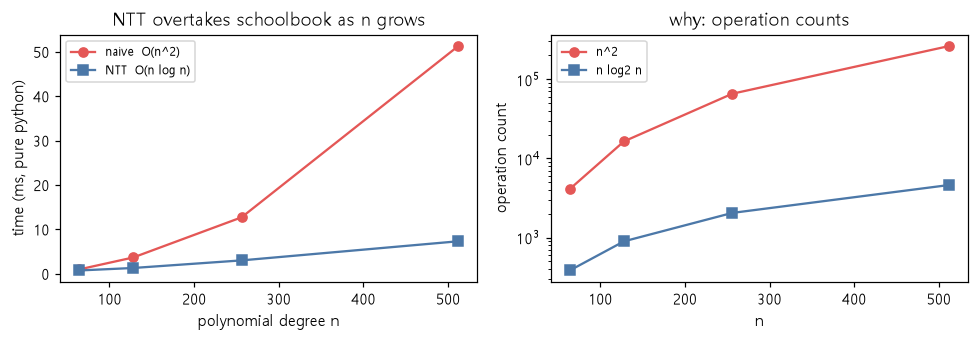

In [31]:
import math
def naive_py(a, b, q, n):
    r=[0]*(2*n-1)
    for i in range(n):
        ai=int(a[i])
        for j in range(n): r[i+j]+=ai*int(b[j])
    return [(r[i]-(r[i+n] if i+n<2*n-1 else 0))%q for i in range(n)]

Q=12289                                          # 1024 | q-1 → n up to 512+
ns=[64,128,256,512]; tn=[]; tt=[]
for nn in ns:
    ps=root_of_order(Q,2*nn)
    a=RNG.integers(0,Q,nn); b=RNG.integers(0,Q,nn)
    (_,dt1)=timeit(naive_py, list(a), list(b), Q, nn, repeat=3); tn.append(dt1*1e3)
    (_,dt2)=timeit(negamul_ntt, a, b, Q, nn, ps, repeat=3); tt.append(dt2*1e3)
fig, ax = plt.subplots(1,2,figsize=(9,3.2))
ax[0].plot(ns,tn,'o-',label='naive  O(n^2)',color='#E45756')
ax[0].plot(ns,tt,'s-',label='NTT  O(n log n)',color='#4C78A8')
ax[0].set_xlabel('polynomial degree n'); ax[0].set_ylabel('time (ms, pure python)')
ax[0].set_title('NTT overtakes schoolbook as n grows'); ax[0].legend(fontsize=8)
ax[1].plot(ns,[x*x for x in ns],'o-',label='n^2',color='#E45756')
ax[1].plot(ns,[x*math.log2(x) for x in ns],'s-',label='n log2 n',color='#4C78A8')
ax[1].set_yscale('log'); ax[1].set_xlabel('n'); ax[1].set_ylabel('operation count')
ax[1].set_title('why: operation counts'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
log_metric('NTT', match='O(n log n)==naive', speedup=f'{tn[-1]/tt[-1]:.1f}x @ n={ns[-1]}')

### 2-3. 결과 해석

왼쪽 그래프는 실측 시간(ms, 1000분의 1초)입니다. $n$ 이 커질수록 순진한 곱(빨간선,
$O(n^2)$ — $n$ 이 2배면 일이 4배)은 급격히 치솟고, NTT(파란선, $O(n\log n)$ — 거의 비례 수준)는
완만하게 증가하여 $n=512$ 에서 격차가 가장 큽니다. 오른쪽의 이론 연산량 그래프
(로그 스케일, 눈금 한 칸 = 10배)를 보면 이 차이가 우연이 아니라 $n^2$ 대 $n\log n$ 이라는
연산량 차이에서 오는 필연임을 알 수 있습니다.

격자 암호는 다항식 곱을 끊임없이 수행합니다. 그러니 이 곱을 "정석대로 한 자리씩"($n^2$) 하느냐
"변환해서 한꺼번에"($n\log n$) 하느냐가 암호 전체의 속도를 결정합니다.
**Kyber·Dilithium이 빠른 근본적인 이유가 NTT이며**, PQC 가속 하드웨어·라이브러리의 성능 비교에서는
NTT 구현 품질이 사실상 순위를 결정합니다.

### 2-4. 실무 적용성 — 실제 파라미터 (RV-PQC 리포트 §4)

| 알고리즘 | 유형 | NTT 사용 | 차수 $n$ | 모듈러스 $q$ | 비고 |
|---|---|---|---|---|---|
| **Kyber** | KEM | 사용 | 256 | 3329 | 정수 NTT, 대부분 PQC 가속기의 기준 |
| **Dilithium** | 서명 | 사용 | 256 | 8380417 | Kyber와 같은 NTT 코어, 큰 $q$ |
| **Falcon** | 서명 | FFT(부동소수점) | 512/1024 | 12289 | 정수 NTT가 아닌 부동소수점 FFT |
| **NTRU** | KEM | 유사 구조 | 701 | 2048/4096 | 순환 합성곱 |
| **McEliece/HQC** | 코드 기반 | 미사용 | — | — | GF(2) 비트연산·복호 (NTT 무관) |

- **하드웨어 함의**: Kyber와 Dilithium이 **같은 NTT 코어**($n=256$)를 쓰기 때문에,
  가속 장치 하나로 KEM과 서명을 모두 처리할 수 있습니다 — 엔진 하나로 두 기능을 돌리는 셈이라
  칩 설계에서 큰 이득입니다. 병렬 처리 폭($P$, $W$)을 키우면 다항식 곱이 128클록에서
  64클록으로 줄어듭니다(리포트 §4).
- 실제 Kyber의 $q=3329$ 는 조건이 살짝 어긋나 **불완전 NTT(incomplete NTT)** 라는 변형을
  씁니다. 이 노트북은 원리를 명확히 보이기 위해 조건이 딱 맞는 친화 소수($q=7681, 12289$)를
  사용했습니다.

> **정리**: NTT는 격자 암호의 속도를 결정하는 심장입니다.
> Kyber와 Dilithium이 같은 NTT 엔진을 공유한다는 점이 하드웨어 설계의 열쇠입니다.


## 3. Keccak / SHAKE — 작은 시드에서 거대한 행렬로

Kyber 공개키에 들어가는 큰 숫자표 $A$ 를 통째로 주고받는 것은 낭비입니다. 대신
**32바이트짜리 씨앗(시드) $\rho$ 만** 주고받고, 보내는 쪽과 받는 쪽이 **각자 같은 방법으로
그 씨앗을 키워** 똑같은 $A$ 를 만들어 냅니다(RV-PQC 리포트 §5).
꽃밭 사진(큰 데이터)을 통째로 보내는 대신 씨앗 봉투 하나만 보내고,
"같은 씨앗 + 같은 재배법 = 같은 꽃밭"인 셈입니다.

그 "재배법" 역할을 하는 것이 **SHAKE128** 입니다. SHAKE는 **XOF(Extendable-Output Function,
가변길이 출력 해시)** — 즉 입력 하나를 넣으면 **원하는 길이만큼** 무작위처럼 보이는 출력을
계속 뽑아 쓸 수 있는 함수입니다. 같은 씨앗을 넣으면 언제나 정확히 같은 출력이 나오므로
(결정론적), 받는 쪽이 표를 스스로 재생성할 수 있습니다. Kyber에서는 시드 확장뿐 아니라
키 유도(KDF)·메시지 해시까지 모두 이 Keccak 계열 함수로 처리합니다.

### 3-1. 검증 — 시드 → SHAKE → 행렬 $A$

앞의 mini-Kyber 구현에서는 $A$ 를 일반 난수로 생성했습니다. 아래 셀은 이를
"씨앗 → SHAKE → $A$" 방식으로 바꾼 `expand_A` 를 구현하고, 같은 씨앗이 같은 $A$ 를,
다른 씨앗이 다른 $A$ 를 주는지, 그리고 전송량이 얼마나 줄어드는지 확인합니다.


In [32]:
# ③④ SHAKE 기반 시드 확장 — 32B 시드 하나로 행렬 A 재생성
def expand_A(seed, k, n, q):
    A = np.zeros((k, k, n), dtype=np.int64)
    for i in range(k):
        for j in range(k):
            buf = hashlib.shake_128(seed + bytes([i, j])).digest(n * 2)   # XOF 추출
            A[i, j] = np.frombuffer(buf, dtype=np.uint16).astype(np.int64) % q
    return A

seed = secrets.token_bytes(32)
A_alice = expand_A(seed, 2, 16, 3329)
A_bob   = expand_A(seed, 2, 16, 3329)      # 밥은 시드만 받고 스스로 A 재생성
A_eve   = expand_A(secrets.token_bytes(32), 2, 16, 3329)
print(f'같은 시드 → 같은 A : {np.array_equal(A_alice, A_bob)}')
print(f'다른 시드 → 다른 A : {not np.array_equal(A_alice, A_eve)}')
full_A_bytes = A_alice.size * 2
print(f'전송량: 시드 {len(seed)} B  vs  A 전체 {full_A_bytes} B  →  {full_A_bytes//len(seed)}배 절감')
log_metric('SHAKE', seed_bytes=len(seed), full_A_bytes=int(full_A_bytes))

같은 시드 → 같은 A : True
다른 시드 → 다른 A : True
전송량: 시드 32 B  vs  A 전체 128 B  →  4배 절감


### 3-2. 결과 해석과 의미

출력이 보여 주듯 같은 씨앗은 같은 $A$ 를(`True`), 다른 씨앗은 다른 $A$ 를(`True`) 만들었습니다.
이 축소 예제($k=2$, $n=16$)에서도 전송량은 표 전체 128바이트 대신 씨앗 32바이트로
**4배 절감**입니다. 실제 Kyber 크기($n=256$)에서는 절감 폭이 훨씬 커집니다.

- 실제 Kyber 공개키는 "압축된 결과값 $\mathbf{t}$ + 씨앗 $\rho$"만 담습니다.
  공개키가 작아지는 비결이 바로 이것입니다.
- 하드웨어에서는 **Keccak(씨앗 키우기 엔진)이 난수를 만들고 → NTT(곱셈 엔진)가 이를 소비**하는
  조립 라인(파이프라인)을 구성합니다. 앞 공정이 너무 느리면 뒤 공정이 놀게 되므로,
  두 엔진의 속도를 맞추는 것(Keccak 언롤 팩터 $u$ 조절, 리포트 §6)이 RV-PQC 설계의 핵심입니다.

> **정리**: "표 대신 씨앗만 보내기(시드 확장)" 덕분에 공개키가 작아지고,
> 그 씨앗을 키워 내는 Keccak의 속도가 전체 성능을 좌우합니다.


## 4. 사이드채널 방어 — 상수시간 · 스크램블 · 마스킹

**수학적으로 안전한 알고리즘도, 구현에서 정보가 새면 뚫립니다.** 금고 자체는 완벽해도
다이얼을 돌릴 때 나는 미세한 소리로 비밀번호가 새는 것과 같습니다. 이렇게 계산 과정에서
새어 나오는 곁가지 신호 — **실행 시간, 캐시(임시 저장소) 사용 흔적, 전력 소모·전자파** — 를
훔쳐보는 공격을 **사이드채널(부채널) 공격**이라고 합니다(PQC ISA 문서의 위협 모델).
방어 기법은 크게 세 가지입니다.

- **상수시간(Constant-time)**: 비밀값이 무엇이든 실행 시간과 메모리 접근 패턴이
  **항상 똑같게** 만듭니다. "일찍 끝내기(조기종료)"와 "비밀값에 따라 갈림길 타기"를 금지합니다.
- **스크램블(Scramble)**: 메모리(RAM)에 두는 데이터를 뒤섞어 저장해서(FNV-1a 해시 등 이용),
  메모리를 엿봐도 알아볼 수 없게 합니다. 추가 비용이 거의 없는 방어입니다.
- **마스킹(Masking)**: 비밀을 무작위 조각(셰어)으로 쪼개 둡니다 — $x = s_1 \oplus s_2$
  (비밀 $x$ 를 무작위 조각 $s_1$ 과, 그것과 XOR하면 $x$ 가 되는 조각 $s_2$ 로 분할).
  지도 반쪽 하나만 훔쳐서는 보물 위치를 전혀 알 수 없듯, 한 조각만 관측해서는
  비밀에 대한 어떤 정보도 얻을 수 없어 전력분석을 방어합니다.

### 4-1. 실험 (1) — 타이밍 사이드채널 실측

아래 셀은 32바이트 비밀 태그와의 비교 함수 두 가지를 만듭니다 —
틀린 글자를 만나면 곧바로 그만두는 **조기종료 비교**(`cmp_naive`)와,
맞든 틀리든 항상 끝까지 다 확인하는 **상수시간 비교**(`cmp_consttime`).
그리고 "앞 $p$ 바이트만 일치"하는 입력($p = 0, 4, \dots, 32$)에 대해
각 6000회 평균 실행 시간을 재서 그래프로 그립니다.


naive 비교: 앞 일치 0B 274ns → 32B 2293ns  (시간이 비밀을 누출!)
const-time: 3405~3779ns  (평평 → 누출 없음)


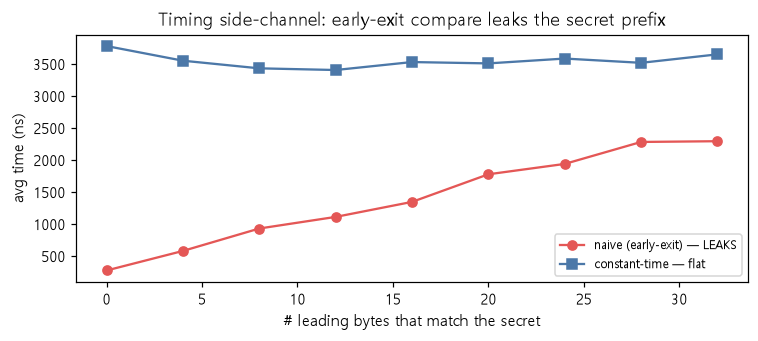

In [33]:
# ③④-(1) 타이밍 사이드채널: 조기종료(누출) vs 상수시간(평평)
SECRET_TAG = secrets.token_bytes(32)
def cmp_naive(guess):                 # 첫 불일치에서 return → 시간이 '앞 일치 길이'를 누출
    for i in range(len(SECRET_TAG)):
        if guess[i] != SECRET_TAG[i]: return False
    return True
def cmp_consttime(guess):             # 항상 전체 스캔 → 누출 없음
    d = 0
    for i in range(len(SECRET_TAG)): d |= guess[i] ^ SECRET_TAG[i]
    return d == 0

def avg_ns(fn, arg, rep=6000):
    t0 = time.perf_counter_ns()
    for _ in range(rep): fn(arg)
    return (time.perf_counter_ns() - t0) / rep

prefixes = list(range(0, 33, 4))
naive_t = []; ct_t = []
for p in prefixes:
    guess = bytes(SECRET_TAG[:p]) + bytes([0xFF]*(32-p))    # 앞 p바이트만 일치
    naive_t.append(avg_ns(cmp_naive, guess))
    ct_t.append(avg_ns(cmp_consttime, guess))
print(f'naive 비교: 앞 일치 0B {naive_t[0]:.0f}ns → 32B {naive_t[-1]:.0f}ns  (시간이 비밀을 누출!)')
print(f'const-time: {min(ct_t):.0f}~{max(ct_t):.0f}ns  (평평 → 누출 없음)')

fig, ax = plt.subplots(figsize=(7,3.2))
ax.plot(prefixes, naive_t, 'o-', label='naive (early-exit) — LEAKS', color='#E45756')
ax.plot(prefixes, ct_t, 's-', label='constant-time — flat', color='#4C78A8')
ax.set_xlabel('# leading bytes that match the secret'); ax.set_ylabel('avg time (ns)')
ax.set_title('Timing side-channel: early-exit compare leaks the secret prefix')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 4-2. 결과 해석

실측에서 조기종료 비교(빨간선)는 앞부분 일치가 0바이트일 때 약 274ns(나노초, 10억분의 1초),
32바이트일 때 약 2293ns로 **약 8배** 차이가 났으며, 일치 길이에 따라 계단처럼 증가했습니다.
즉 **"얼마나 오래 걸렸나"만 보고도 "앞에서 몇 글자를 맞혔나"를 알 수 있습니다.**
상수시간 비교(파란선)는 약 3405~3779ns 범위에서 거의 평평했습니다.

파란선이 더 느린 위치에 있는 것은 손해가 아니라 **일부러 항상 끝까지 검사하기 때문**이며,
그 평평함이 곧 안전입니다. 반대로 조기종료 비교에서는 공격자가 정답을 몰라도 시간만 재면서
"첫 글자를 바꿔 가며 가장 오래 걸리는 것 고르기"를 반복하면 — 자물쇠 다이얼을 한 칸씩 돌리며
걸리는 소리를 듣는 것처럼 — 비밀을 **한 바이트씩** 복원할 수 있습니다.
수학적으로 완벽한 암호도 구현이 이렇게 새면 뚫립니다.

> 실무에서는 비밀값 비교 코드를 직접 짜지 말고, `hmac.compare_digest` 같은
> 검증된 상수시간 API를 사용해야 합니다.

### 4-3. 실험 (2)(3) — 스크램블과 마스킹

아래 셀은 PQC ISA 문서의 scramble 데이터패스를 본떠, FNV-1a 해시로 만든 뒤섞기 열쇠를
XOR로 적용하는 스크램블(같은 키로 두 번 적용하면 원본으로 되돌아오는 성질 이용)을 구현하고,
비밀을 두 조각으로 나누는 불린 마스킹($x = s_1 \oplus s_2$)이 정확히 복원되는지 2000회 확인합니다.


In [34]:
# ③④-(2) FNV-1a 스크램블 (CTR 모드) — PQC ISA 문서의 scramble 데이터패스
def fnv1a32(data):
    h = 0x811c9dc5
    for b in data: h = ((h ^ b) * 0x01000193) & 0xFFFFFFFF
    return h
def fnv_ctr_keystream(key, nbytes):        # AES-CTR 구조에서 AES→FNV-1a 로 치환
    out = bytearray(); ctr = 0
    while len(out) < nbytes:
        out += fnv1a32(key + ctr.to_bytes(4,'little')).to_bytes(4,'little'); ctr += 1
    return bytes(out[:nbytes])
def scramble(data, key):                   # scramble ∘ scramble = 원본 (XOR keystream)
    ks = fnv_ctr_keystream(key, len(data)); return bytes(d ^ k for d, k in zip(data, ks))

# ③④-(3) 불린 마스킹 — 비밀을 두 셰어로 분할
def mask(x, rng): s1 = int(rng.integers(0,256)); return s1, x ^ s1
def unmask(s1, s2): return s1 ^ s2

key_bytes = b'PQC-key!'
payload = b'secret sk material 0123456789ABCDEF'
enc = scramble(payload, key_bytes); dec = scramble(enc, key_bytes)
print(f'[FNV-1a scramble] 왕복 복원 정확: {dec==payload},  스크램블은 원문과 다름: {enc!=payload}')
mok = sum(unmask(*mask(int(RNG.integers(0,256)), RNG)) == v
          for v in [int(RNG.integers(0,256)) for _ in range(1)] for _ in [0])
cnt = 0
for _ in range(2000):
    x = int(RNG.integers(0,256)); s1,s2 = mask(x, RNG); cnt += (unmask(s1,s2)==x)
print(f'[마스킹] x=s1^s2 복원 정확: {cnt}/2000,  각 셰어는 균등난수처럼 보임')
log_metric('SideChannel', ct_flat=bool(max(ct_t)-min(ct_t) < (naive_t[-1]-naive_t[0])),
           scramble_ok=bool(dec==payload), mask_ok=(cnt==2000))

[FNV-1a scramble] 왕복 복원 정확: True,  스크램블은 원문과 다름: True
[마스킹] x=s1^s2 복원 정확: 2000/2000,  각 셰어는 균등난수처럼 보임


### 4-4. 실무 적용성 판단

- **측정 요약**: 조기종료 비교는 실행 시간이 비밀의 앞부분 일치 길이를 그대로 누출했고
  (0B→32B에서 계단식 증가), 상수시간 비교는 평평했습니다. FNV-1a 스크램블은 뒤섞었다
  되돌리는 왕복이 정확했고 뒤섞인 결과는 원문과 달랐으며(둘 다 `True`),
  마스킹도 2000/2000 모두 정확히 복원됐습니다. 각 조각(셰어)은 단독으로는
  그냥 무작위 수처럼 보입니다 — 반쪽만 훔쳐서는 아무것도 알 수 없습니다.
- **원칙(PQC ISA 문서)**: ⑴ 비밀값에 따라 갈림길·배열 위치가 달라지는 코드 금지(상수시간),
  ⑵ 캐시라인(메모리를 한 번에 읽는 단위) 안에서 비밀 위치가 드러나지 않도록
  전체 라인을 통째로 읽기(`PQC.LOAD_LINE`), ⑶ 마스킹으로 전력분석 방어,
  ⑷ 취약점 발견 시 칩을 다시 만들기 전에 **마이크로코드 패치**(하드웨어 안의 작은 소프트웨어
  업데이트)로 즉시 완화.
- **CacheBleed의 교훈**: "상수시간으로 구현했다"던 RSA조차 캐시의 미세한 충돌 현상으로
  뚫린 사례가 있습니다. NTT 구현에서도 비밀값에 따라 메모리를 다르게 건드리는 일이 없어야 합니다.

> **정리**: 알고리즘이 안전해도 구현이 새면 소용없습니다.
> 상수시간·스크램블·마스킹 3종 세트가 구현의 안전벨트입니다.


## 5. RISC-V PQC ISA 매핑 — 알고리즘을 하드웨어 프리미티브로

지금까지 만들어 본 연산들(NTT, 해시, 마스킹 등)을 CPU가 직접 알아듣는
**전용 명령어(프리미티브 — 가장 기본이 되는 부품 명령)** 로 만들어 두면, 어떤 PQC 알고리즘이든
그 블록들을 레고처럼 조립해서 빠르고 안전하게 실행할 수 있습니다.
(RISC-V는 누구나 확장할 수 있는 개방형 CPU 명령어 규격이고, ISA는 "CPU가 알아듣는 명령어 목록"
이라는 뜻입니다.) PQC ISA 문서는 고수준 PQC 연산을 소수의 **상수시간 프리미티브**로 내려
매핑하며, 앞 장들에서 구현한 연산이 그대로 하드웨어 명령이 됩니다.

| ISA 프리미티브 | 하는 일 | 이 노트북 대응 |
|---|---|---|
| `PQC.NTT.BF` | NTT 버터플라이(모듈러 add/sub/mul) | 2장 NTT |
| `PQC.POLY.MUL_ACC` | 다항식 곱·누산 | 1·2장 다항식 곱 |
| `PQC.SHA3.XOF` | SHAKE 흡수/추출(시드 확장) | 3장 SHAKE |
| `PQC.RNG_FILL` | 하드웨어 난수로 스크래치 채움 | 노이즈·시드 생성 |
| `PQC.MASK.LOAD/OP` | 마스크 셰어 적재·마스크 연산 | 4장 마스킹 |
| `PQC.LOAD_LINE` | 캐시 라인 통째 로드(오프셋 누출 차단) | 4장 상수시간 |
| `PQC.MCODE.CALL` | 마이크로코드 완화 루틴(패치) | 4장 패치 가능성 |

**알고리즘 → 프리미티브 매핑(문서 §4)** — 어떤 자물쇠든 같은 부품들로 조립됩니다:

- **Kyber/Dilithium(격자 기반)**: 다항식 곱이 중심이므로 `PQC.NTT.BF` + `PQC.POLY.MUL_ACC` +
  시드 확장 `PQC.SHA3.XOF` 로 조립됩니다. 중간중간의 조건 검사(거부샘플링·노름검사)는
  상수시간 또는 마이크로코드 안전경로로 처리합니다.
- **SPHINCS+(해시 기반)**: 해시 계산이 중심이므로 `PQC.SHA3.XOF` 가 핵심입니다.
  트리 구조를 오르내릴 때 위치(인덱스)가 새기 쉬우므로 `PQC.LOAD_LINE`·마스크 인덱싱이 필수입니다.
- **코드 기반/다변수**: 표 참조가 적어 `PQC.POLY.*` / `PQC.MASK.*` 로 매핑됩니다.

### 5-1. 설계 철학 요약 (Fail-safe & Patchable)

1. **보안 약속을 명령어 규격에 명시** — "이 명령은 항상 같은 시간에 끝나고 위치 정보를
   흘리지 않는다"를 스펙 차원에서 보장합니다.
2. **패치 가능성** — 문제가 발견되면 설정 레지스터(CSR)로 해당 블록을 즉시 끄고 우회하며,
   마이크로코드(하드웨어 안의 작은 소프트웨어)로 완화책을 배포합니다. 칩은 리콜이 어렵기에
   "소프트웨어처럼 고칠 수 있는 여지"를 미리 설계해 두는 것입니다.
3. **검증 가능성** — 시뮬레이터 모델·회로 설계(RTL)·부채널 측정 장비·테스트벡터로 실증합니다.
4. **폴백(안전한 대체 경로)** — 전용 하드웨어가 없거나 꺼져 있으면 상수시간 소프트웨어
   라이브러리로 안전을 유지합니다.

요컨대 앞선 개념·표준 학습이 **"무엇을(어떤 알고리즘)"** 이라면, 이 노트북은
**"어떻게 안전하고 빠르게 실행하는가"** 를 다룹니다. 수학적 안전성(알고리즘) +
구현 안전성(상수시간·마스킹) + 패치 가능성(마이크로코드)이 모두 갖춰져야
실제 제품에서 안전합니다.

> **정리**: 좋은 알고리즘을 "좋은 명령어 블록"으로 내려 앉히는 것이 마지막 퍼즐입니다.
> 수학·구현·패치의 3박자가 맞아야 진짜 안전입니다.


## 연습문제

직접 코드를 수정해 보면서 감을 잡아 보세요. 어려운 수학 없이, 숫자만 바꿔 보면 됩니다.

1. **음순환행렬 크기 확장**: 1장 검증 셀에서 `n, q = 8, 257` 을 `n, q = 16, 257` 로 바꾸고,
   `a_demo` 도 길이 16 배열로 바꿔 실행해 보세요. 대각선 줄무늬와 부호 반전 패턴이
   $n=16$ 에서도 유지되는지, 등가성 검증이 여전히 500/500인지 확인해 보세요.

2. **NTT 벤치마크 확장**: 2장 시각화 셀의 `ns=[64,128,256,512]` 에 `1024` 를 추가해 보세요
   ($q=12289$ 는 조건을 만족하므로 그대로 동작합니다). `log_metric` 에 기록되는
   speedup(속도 향상 배율) 값이 $n=512$ 일 때보다 얼마나 커지는지 관찰해 보세요.

3. **시드 확장 절감률**: 3장의 `expand_A(seed, 2, 16, 3329)` 를 실제 Kyber에 가까운
   `expand_A(seed, 2, 256, 3329)` 로 바꿔 보세요. 표 전체 크기 `full_A_bytes` 가
   몇 바이트가 되고, 32바이트 씨앗 대비 절감 배율이 4배에서 몇 배로 커지는지
   계산과 실행으로 확인해 보세요.

4. **검증된 상수시간 API 비교**: 4장 타이밍 실험에 `hmac.compare_digest(guess, SECRET_TAG)` 를
   세 번째 비교 함수로 추가하고 `avg_ns` 로 측정해 보세요. 직접 만든 `cmp_consttime` 처럼
   그래프가 평평한지, 속도는 어떤지 비교해 보세요. 반복 횟수 `rep` 을 6000에서 늘리면
   곡선이 더 매끈해지는 이유(짧은 시간 측정의 잡음을 평균으로 지우기)도 생각해 보세요.


## 요약

- **LWE → RLWE → Module-LWE**: 다항식 곱은 음순환행렬 곱과 정확히 같다(500/500 검증).
  큰 표(행렬)를 다항식 한 줄로 압축한 것이 RLWE, 다항식을 묶어 규칙성의 편향을 완화한 것이
  Module-LWE다 — 갈수록 같은 안전성을 더 작게 담는다.
- **NTT**는 다항식 곱을 $O(n^2)$("$n$ 이 2배면 일이 4배")에서 $O(n\log n)$(거의 비례)으로
  줄이며(순진곱과 30/30 일치), $n$ 이 커질수록 순진곱을 압도한다.
  Kyber·Dilithium은 같은 $n=256$ NTT 코어를 공유한다 — 엔진 하나로 KEM과 서명을 모두 돌린다.
- **SHAKE 시드 확장**: 큰 표 대신 32바이트 씨앗만 보내고 받는 쪽이 같은 방법으로 키워 낸다
  ("같은 씨앗 + 같은 재배법 = 같은 꽃밭"). 공개키가 작아지는 비결이며, 하드웨어에서는
  Keccak과 NTT의 속도 맞추기가 설계의 핵심이다.
- **사이드채널 방어**: 조기종료 비교는 실행 시간으로 비밀을 흘리지만(실측 약 8배 차이)
  상수시간 비교는 평평하다. 여기에 스크램블(메모리 뒤섞기)·마스킹(비밀 쪼개기)까지
  3종 세트가 구현의 안전벨트다.
- **RISC-V PQC ISA**는 이 연산들을 상수시간 전용 명령어(`PQC.NTT.BF`, `PQC.SHA3.XOF`,
  `PQC.MASK.*` 등)로 만들어 레고처럼 조립하게 하고, 마이크로코드 패치로 출시 후 완화까지
  보장한다.

> 수학적 안전성은 시작일 뿐입니다. 상수시간 구현, 사이드채널 방어, 그리고 패치 가능한
> 하드웨어까지 갖춰져야 PQC가 실제 제품에서 안전하게 동작합니다.
